In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snb
import warnings

warnings.filterwarnings('ignore')

# import two datasets
df1 = pd.read_csv('tmdb_5000_credits.csv')
df2 = pd.read_csv('tmdb_5000_movies.csv')


In [13]:
# merge two dataset
df1.columns = ['id','tittle','cast','crew']
df2= df2.merge(df1,on='id')

In [14]:
df2.head(5)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,tittle,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [15]:

df2.shape

(938, 23)

In [16]:
# see the info
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                938 non-null    int64  
 1   genres                938 non-null    object 
 2   homepage              503 non-null    object 
 3   id                    938 non-null    int64  
 4   keywords              938 non-null    object 
 5   original_language     938 non-null    object 
 6   original_title        938 non-null    object 
 7   overview              938 non-null    object 
 8   popularity            938 non-null    float64
 9   production_companies  938 non-null    object 
 10  production_countries  938 non-null    object 
 11  release_date          938 non-null    object 
 12  revenue               938 non-null    int64  
 13  runtime               938 non-null    float64
 14  spoken_languages      938 non-null    object 
 15  status                9

In [17]:
df2['release_date'] = pd.to_datetime(df2['release_date'])

In [18]:
# check if there's missing value
df2.isnull().sum()

,0
budget,0
genres,0
homepage,435
id,0
keywords,0
original_language,0
original_title,0
overview,0
popularity,0
production_companies,0


In [19]:
# fill the missing value
df2['overview'] = df2['overview'].fillna('') # fill with empty string
df2['runtime'] = df2['runtime'].fillna(df2['runtime'].median()) # fill with median value
df2 = df2.dropna(subset=['release_date']) # since there's only one missing value, just remove it
df2 = df2.drop('homepage', axis=1)
df2['tagline'] = df2['tagline'].fillna('')


In [20]:
# check columns exist
df2[['title', 'vote_average', 'vote_count']].head()

,title,vote_average,vote_count
0,Avatar,7.2,11800
1,Pirates of the Caribbean: At World's End,6.9,4500
2,Spectre,6.3,4466
3,The Dark Knight Rises,7.6,9106
4,John Carter,6.1,2124


In [21]:
df2.isnull().sum()

,0
budget,0
genres,0
id,0
keywords,0
original_language,0
original_title,0
overview,0
popularity,0
production_companies,0
production_countries,0


In [22]:
# look at some statistics
df2[['vote_average', 'vote_count']].describe()

,vote_average,vote_count
count,938.000000,938.000000
mean,6.231876,1816.688699
std,0.809467,2015.049064
min,3.000000,1.000000
25%,5.700000,451.500000
50%,6.200000,1121.500000
75%,6.700000,2368.000000
max,8.300000,13752.000000


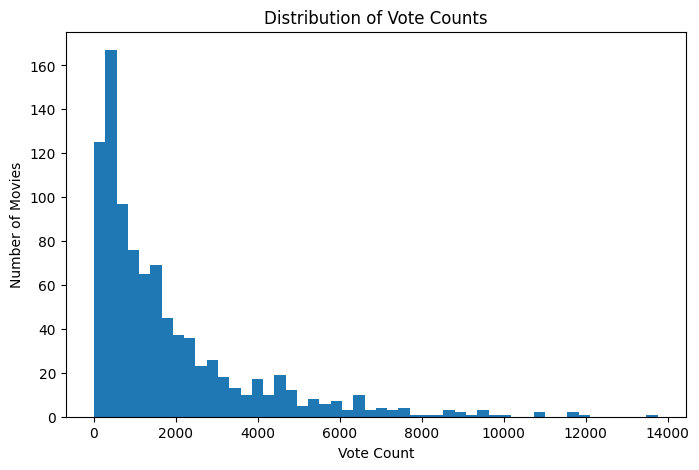

In [23]:
# MIN_VOTES = 200????
import matplotlib.pyplot as plt

# Create a new figure/chart area
# figsize=(8, 5) means the chart size is 8 inches wide and 5 inches tall
plt.figure(figsize=(8, 5))

# Create a histogram of the vote_count column
# A histogram shows how often different ranges of values appear
# bins=50 means the vote counts are divided into 50 groups/ranges
plt.hist(df2['vote_count'], bins=50)

plt.xlabel("Vote Count")
plt.ylabel("Number of Movies")
plt.title("Distribution of Vote Counts")
plt.show()

In [25]:
# change the text to number, make it easy to compare
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df2['overview'])
tfidf_matrix.shape

(938, 8548)

In [26]:
# compare similiar of every movie to every other movie
from sklearn.metrics.pairwise import linear_kernel
cosine = linear_kernel(tfidf_matrix, tfidf_matrix) # cosine contains the similiarity scores between every movie
cosine.shape

(938, 938)

In [27]:
# u can search a movie by its name instead of row number.
df2 = df2.reset_index()
indice = pd.Series(df2.index, index=df2['title']).drop_duplicates()

In [28]:
# which does it actual recommending
def recommendations(title, cosine=cosine):
    idx = indice[title] # this finds the row number of the movie
    sim_score = list(enumerate(cosine[idx])) # this get the similarity scores between selected movie and every movie
    #e.g., [(1, 0.20),
    #        (2, 0.75),
    #        (3, 0.50)] the left are row number, and the right are similarity scores.
    sim_score = sorted(sim_score,
                       key=lambda x: x[1],
                       reverse=True) # sort using the second value, from highest to lowest
    sim_score = sim_score[1:11] # select the next 10 most similar movie, start from 1 because the first one is the searched movie itself.
    indices = [i[0] for i in sim_score] # collect the movie row number
    return df2['title'].iloc[indices] # use row number to return movie title

#what i've done in here:
#find the movie -> get all similarity score -> sort them -> remove the movie itself -> choose top 10 -> return their title


In [29]:
# test
recommendations('The Dark Knight Rises')

,title
299,Batman Forever
65,The Dark Knight
428,Batman Returns
119,Batman Begins
9,Batman v Superman: Dawn of Justice
210,Batman & Robin
879,Law Abiding Citizen
790,American Sniper
771,Dragonfly
647,World Trade Center
